In [ ]:
import warnings
warnings.simplefilter(action='ignore')

import scanpy as sc
import numpy as np
import pandas as pd
import torch
import scarches as sca
import sys

 captum (see https://github.com/pytorch/captum).


In [2]:
sc.set_figure_params(frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

perc = 1
top_genes = None
condition_key = 'cancer_subtype'

adata_path = f'/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/anndata_inputs/adata_top_{perc}_top_genes_{top_genes}.h5ad'
model_path = f'/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/trained_models/model_{perc}_top_genes_{top_genes}_{condition_key}'

adata = sc.read_h5ad(adata_path)

#if condition_key != 'placeholder_condition':
#    adata.obs["placeholder_condition"] = "placeholder"

vae = sca.models.EXPIMAP.load(model_path, adata, map_location='cpu')

full_model = vae.model
encoder = full_model.encoder
decoder = full_model.decoder

adata = sc.read_h5ad(adata_path)

AnnData object with n_obs × n_vars = 4544 × 15984
    obs: 'cancer_subtype'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_idx', 'counts_in_terms', 'gene_as_regulator'
    uns: 'cancer_subtype_colors', 'hvg', 'log1p', 'neighbors', 'nsd2_as_regulator', 'nsd2_as_target', 'pca', 'terms', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'I', 'PCs'
    layers: 'X_normalized', 'counts'
    obsp: 'connectivities', 'distances'

INITIALIZING NEW NETWORK..............
Encoder Architecture:
	Input Layer in, out and cond: 15984 300 3
	Hidden Layer 1 in/out: 300 300
	Hidden Layer 2 in/out: 300 300
	Mean/Var Layer in/out: 300 2532
Decoder Architecture:
	Masked linear layer in, ext_m, ext, cond, out:  2532 0 0 3 15984
	with hard mask.
Last Decoder layer: softmax


In [3]:
adata

AnnData object with n_obs × n_vars = 4544 × 15984
    obs: 'cancer_subtype'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_idx', 'counts_in_terms', 'gene_as_regulator'
    uns: 'cancer_subtype_colors', 'hvg', 'log1p', 'neighbors', 'nsd2_as_regulator', 'nsd2_as_target', 'pca', 'terms', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'I', 'PCs'
    layers: 'X_normalized', 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
sc.tl.rank_genes_groups(adata, groupby='cancer_subtype', method='wilcoxon')

In [5]:
pd.DataFrame(adata.uns['rank_genes_groups']['pvals_adj'])

,CRPC-NE,CRPC-adeno,DNPC
0,0.000000e+00,0.000000e+00,0.909652
1,0.000000e+00,0.000000e+00,0.950216
2,0.000000e+00,0.000000e+00,0.969952
3,0.000000e+00,0.000000e+00,0.954293
4,0.000000e+00,0.000000e+00,0.954293
...,...,...,...
15979,2.013415e-108,9.351698e-71,0.000000
15980,1.902946e-111,1.828976e-72,0.000000
15981,7.088148e-114,6.138278e-74,0.000000
15982,2.673716e-119,5.661867e-75,0.000000


In [6]:
pd.DataFrame(adata.uns['rank_genes_groups']['names'])

,CRPC-NE,CRPC-adeno,DNPC
0,Stmn3,S100a6,Gm26873
1,Uchl1,Anxa2,Ifi27l2b
2,Bex2,S100a11,Col8a2
3,Chga,Ifitm3,1700123K08Rik
4,Btg2,Lgals1,4933433G15Rik
...,...,...,...
15979,Tubb6,Rundc3a,Atpif1
15980,Mgst1,Pkib,Ywhaz
15981,Vim,Elavl3,H3f3b
15982,Cp,Pou2f2,Cox7a2


In [7]:
adata

AnnData object with n_obs × n_vars = 4544 × 15984
    obs: 'cancer_subtype'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_idx', 'counts_in_terms', 'gene_as_regulator'
    uns: 'cancer_subtype_colors', 'hvg', 'log1p', 'neighbors', 'nsd2_as_regulator', 'nsd2_as_target', 'pca', 'terms', 'umap', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'I', 'PCs'
    layers: 'X_normalized', 'counts'
    obsp: 'connectivities', 'distances'

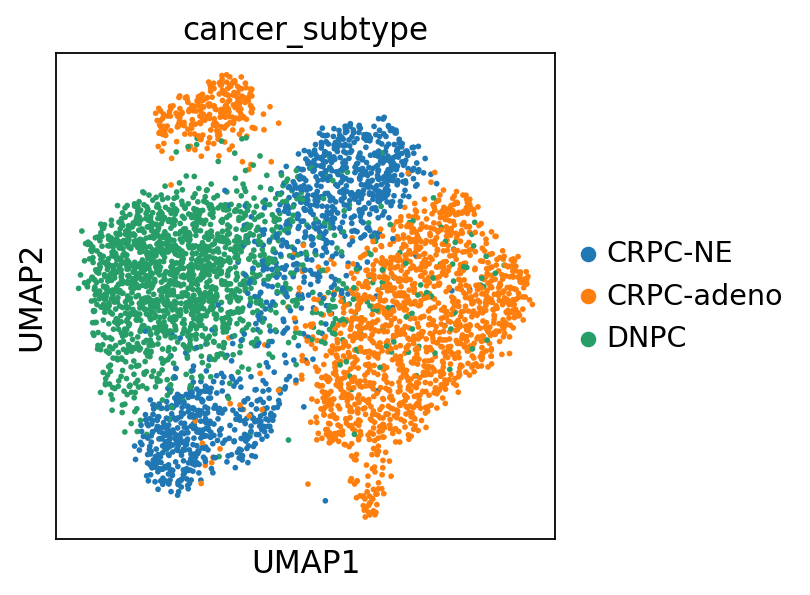

In [8]:
adata.obsm['vae_latent'] = vae.get_latent(
    x=adata.X, 
    c=adata.obs[condition_key].values,
    only_active=True)

sc.pp.neighbors(adata, use_rep='vae_latent')

sc.tl.umap(adata)
sc.pl.umap(adata, color='cancer_subtype')

In [9]:
#e_distance = vae.e_distance(adata, cluster_key='cancer_subtype', embedding_key='vae_latent', n_jobs=-1)

In [10]:
adata

AnnData object with n_obs × n_vars = 4544 × 15984
    obs: 'cancer_subtype'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_idx', 'counts_in_terms', 'gene_as_regulator'
    uns: 'cancer_subtype_colors', 'hvg', 'log1p', 'neighbors', 'nsd2_as_regulator', 'nsd2_as_target', 'pca', 'terms', 'umap', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap', 'vae_latent'
    varm: 'I', 'PCs'
    layers: 'X_normalized', 'counts'
    obsp: 'connectivities', 'distances'

In [11]:
ne_vs_adeno = ['CRPC-NE', 'CRPC-adeno']
all_groups   = 'all'
groups       = [ne_vs_adeno, all_groups]
dics = []

for grp in groups:
    result = vae.differential_expression(
        adata,
        groupby='cancer_subtype',
        method="wilcoxon",
        layer='X_normalized',
        groups_to_compare=grp,
        reference=None
    )
    dics.append(result.uns['rank_genes_groups'])

Subsetted to groups: ['CRPC-NE', 'CRPC-adeno']
Differential expression completed.
Differential expression completed.


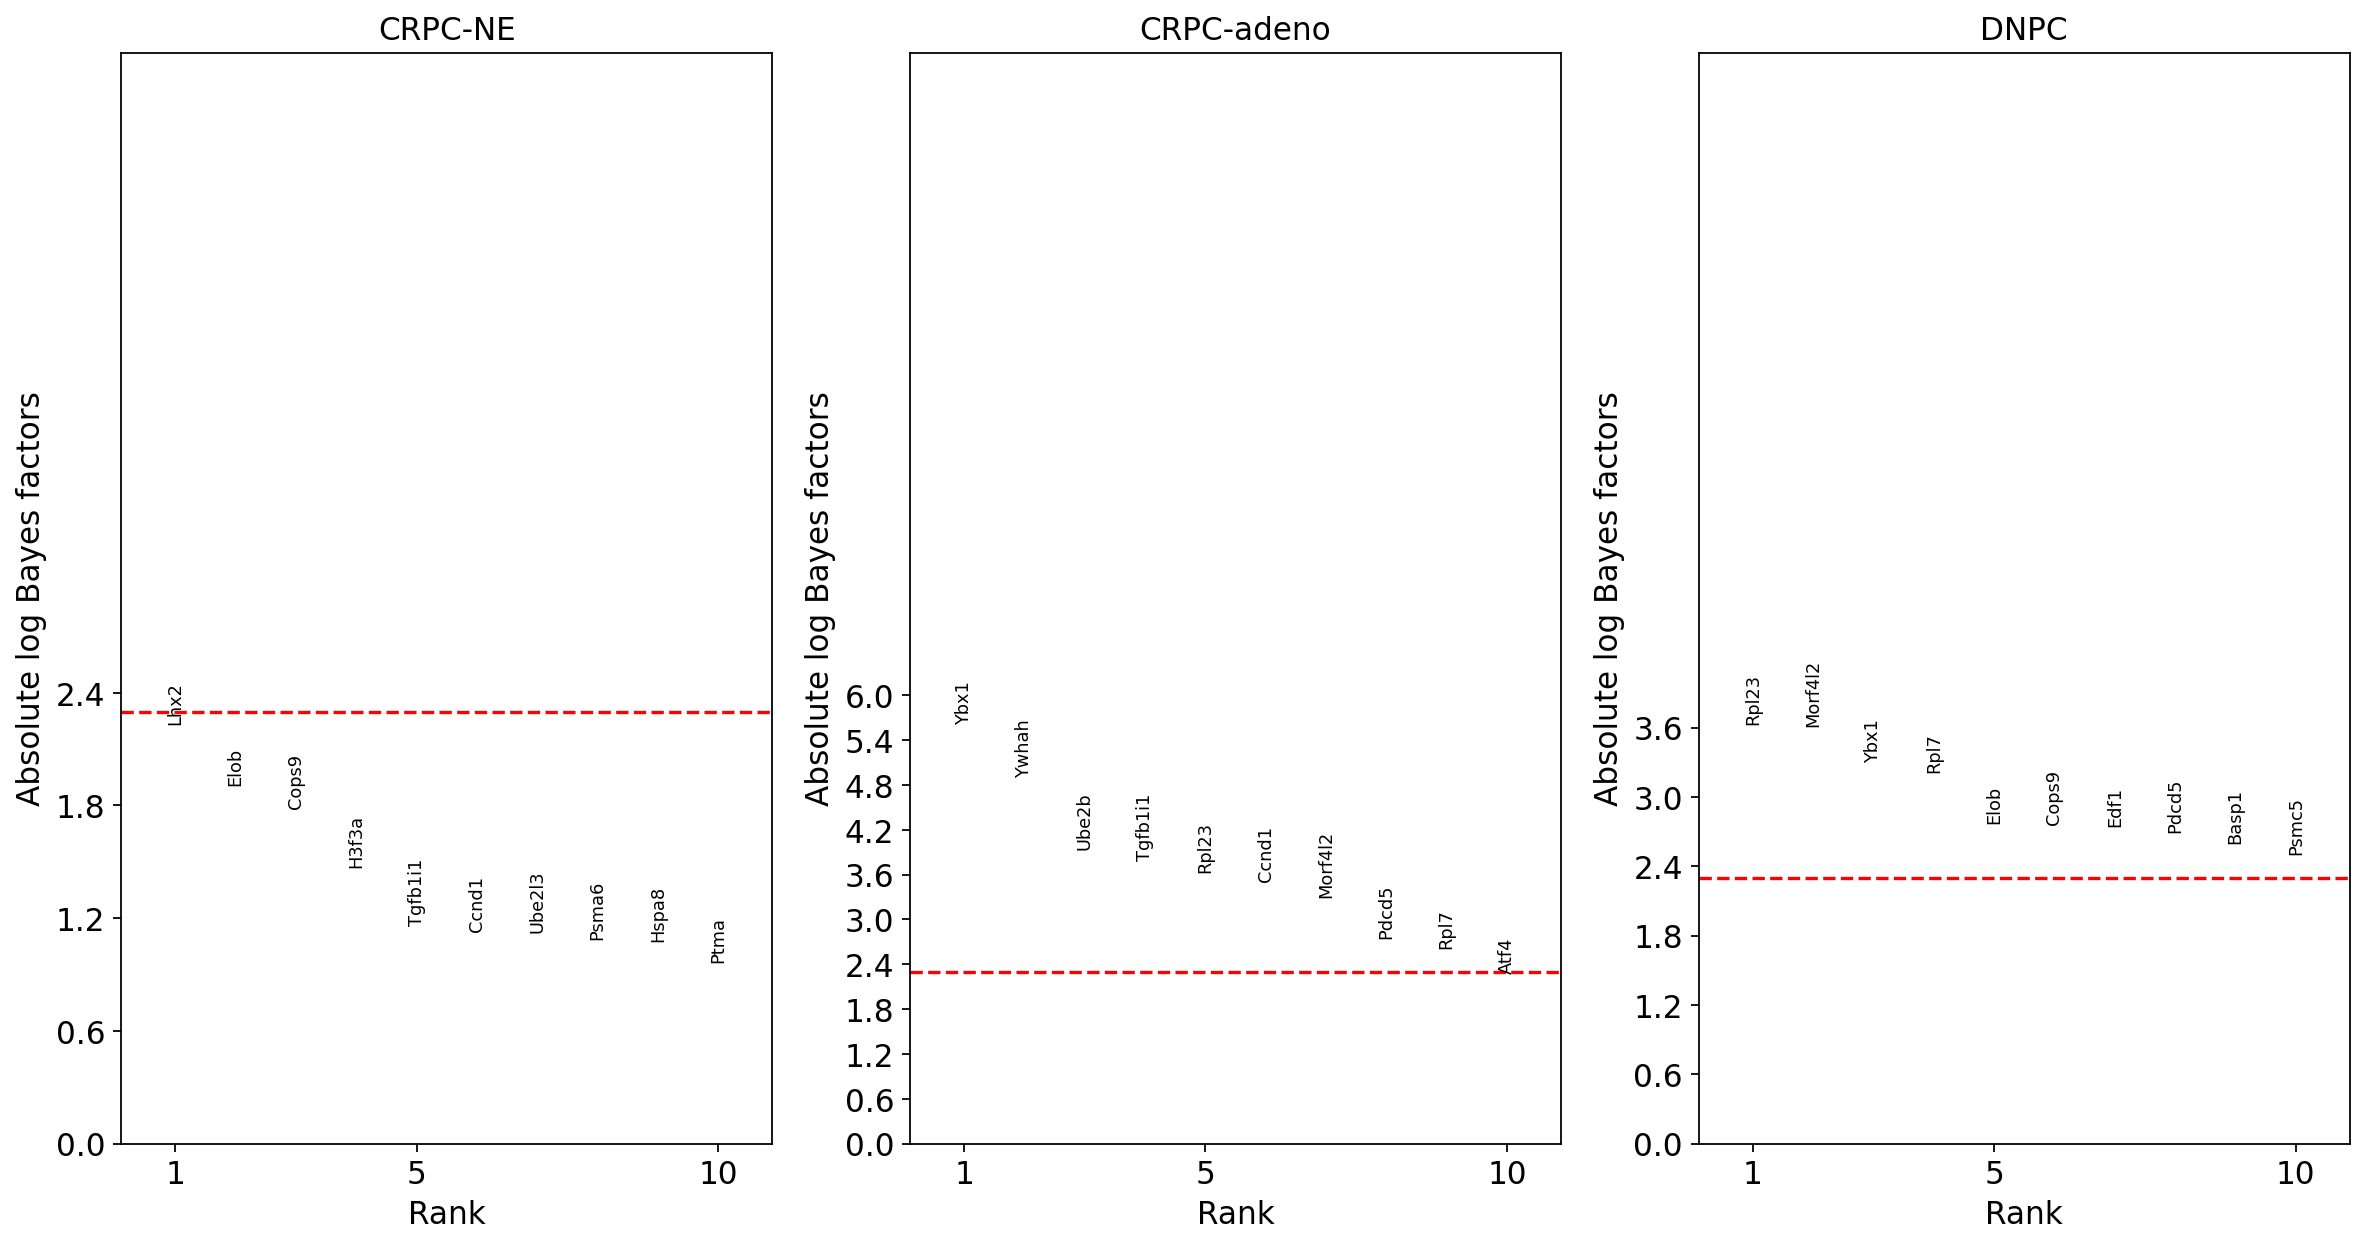

In [12]:
vae.latent_directions(adata=adata)
n_samples = min(adata.obs['cancer_subtype'].value_counts())
vae.latent_enrich(groups='cancer_subtype', use_directions=False, adata=adata, n_sample=n_samples)

fig = sca.plotting.plot_abs_bfs(
    adata,
    n_cols=3,
    scale_y=2.6,
    yt_step=0.6,
    figsize=(15, 8),  # Increase figure size
    n_points=10,
)

In [13]:
for perturb_type in ['KO', 'Overexpression']:
    pert_gene_adata = vae.perturb_genes(
        adata=adata,
        genes='Nsd2',
        perturb_type=perturb_type,
        group_key='cancer_subtype',
        category='CRPC-NE',
        obs_key='perturbation',
        condition_key='cancer_subtype',
        new_condition=None
    )

    e_distance_z = vae.e_distance(pert_gene_adata, cluster_key='cancer_subtype_perturb', embedding_key='z1_mean_all', n_jobs=-1)
    pert_gene_adata.obsm['perturbed_dec_mean'] = pert_gene_adata.layers['perturbed_dec_mean']
    e_distance_gene = vae.e_distance(pert_gene_adata, cluster_key='cancer_subtype_perturb', embedding_key='perturbed_dec_mean', n_jobs=-1)

                 CRPC-NE  CRPC-NE_perturb  CRPC-adeno    DNPC
CRPC-NE           0.0000           0.0000      2.9087  6.8117
CRPC-NE_perturb                    0.0000      2.9081  6.8131
CRPC-adeno                                     0.0000 11.0093
DNPC                                                   0.0000
                 CRPC-NE  CRPC-NE_perturb  CRPC-adeno   DNPC
CRPC-NE           0.0000           0.0000      0.0240 0.0131
CRPC-NE_perturb                    0.0000      0.0240 0.0131
CRPC-adeno                                     0.0000 0.0132
DNPC                                                  0.0000
                 CRPC-NE  CRPC-NE_perturb  CRPC-adeno    DNPC
CRPC-NE           0.0000           0.0002      2.9087  6.8117
CRPC-NE_perturb                    0.0000      2.9109  6.8081
CRPC-adeno                                     0.0000 11.0093
DNPC                                                   0.0000
                 CRPC-NE  CRPC-NE_perturb  CRPC-adeno   DNPC
CRPC-NE       

In [14]:
ne_vs_adeno = ['CRPC-NE', 'CRPC-adeno']
all_groups   = 'all'
groups       = [ne_vs_adeno, all_groups]
dics = []

for grp in groups:
    result = vae.differential_expression(
        pert_gene_adata,
        groupby='cancer_subtype_perturb',
        method="wilcoxon",
        layer='perturbed_dec_mean',
        groups_to_compare=grp,
        reference=None
    )
    dics.append(result.uns['rank_genes_groups'])

Subsetted to groups: ['CRPC-NE', 'CRPC-adeno']
Differential expression completed.
Differential expression completed.


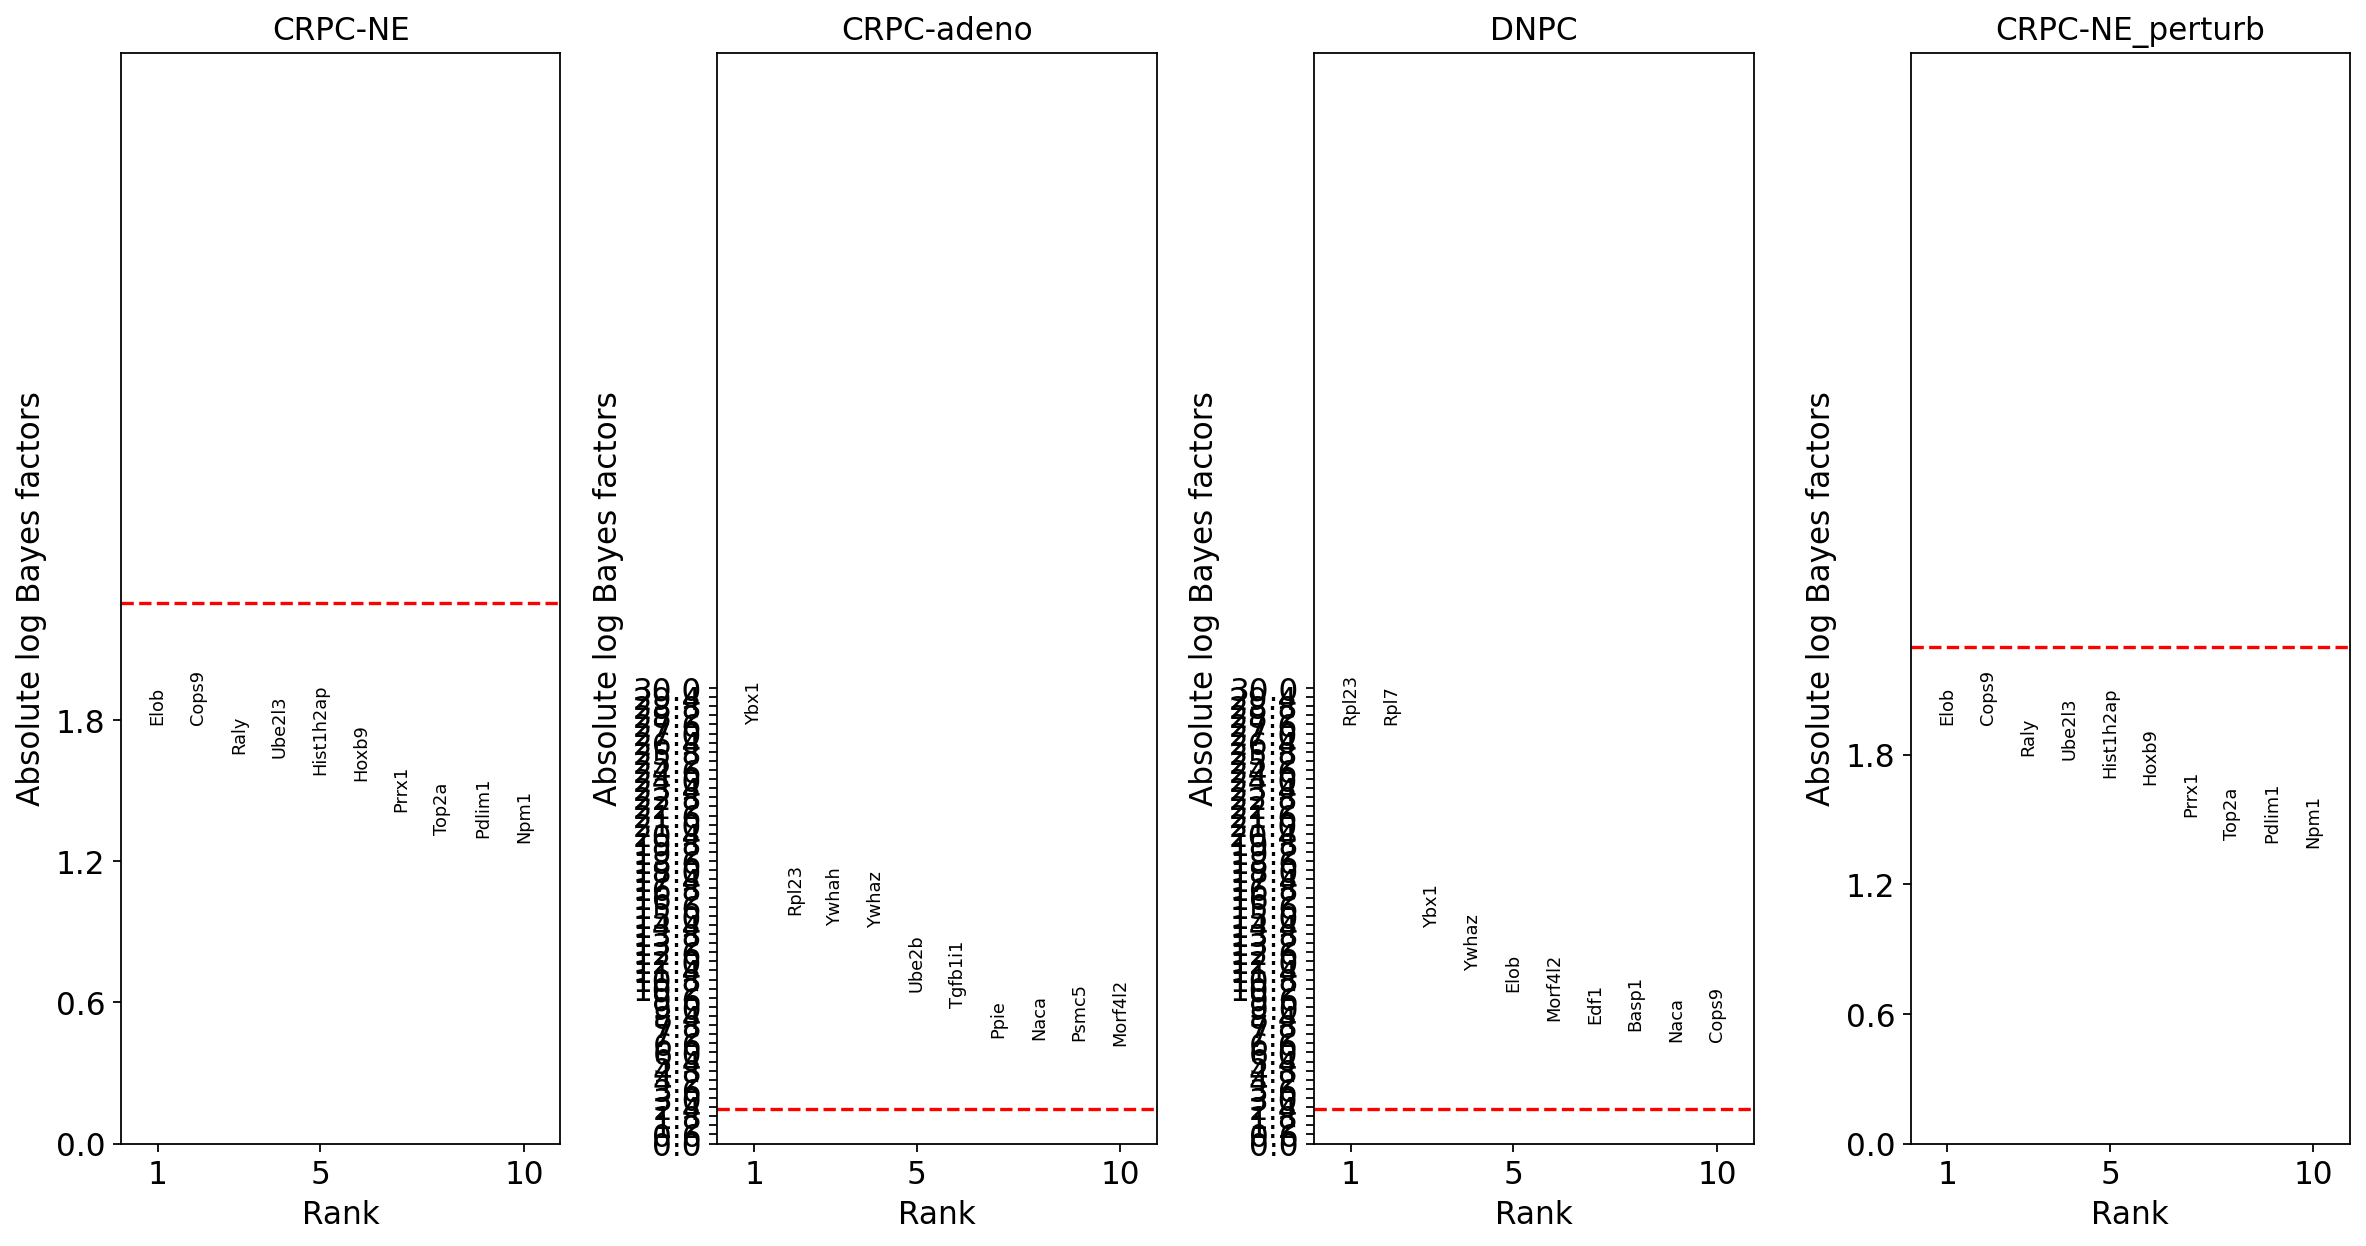

In [15]:
vae.latent_directions(adata=pert_gene_adata)
n_samples = min(pert_gene_adata.obs['cancer_subtype_perturb'].value_counts())
vae.latent_enrich(groups='cancer_subtype_perturb', use_directions=False, adata=pert_gene_adata, n_sample=n_samples)
pert_gene_adata.uns['terms'] = adata.uns['terms']
fig = sca.plotting.plot_abs_bfs(
    pert_gene_adata,
    n_cols=4,
    scale_y=2.6,
    yt_step=0.6,
    figsize=(15, 8),  # Increase figure size
    n_points=10,
)


In [16]:
for perturb_type in ['KO', 'Overexpression']:
    pert_gp_adata = vae.perturb_gps(
        adata=adata,
        programs='Nsd2',
        perturb_type=perturb_type,
        group_key='cancer_subtype',
        category='CRPC-NE',
        obs_key='perturbation',
        condition_key='cancer_subtype',
        new_condition=None
    )

    pert_gp_adata.obsm['perturbed_dec_mean'] = pert_gp_adata.layers['perturbed_dec_mean']
    e_distance_z = vae.e_distance(pert_gp_adata, cluster_key='cancer_subtype_perturb', embedding_key='perturbed_dec_mean', n_jobs=-1)
    e_distance_gene = vae.e_distance(pert_gp_adata, cluster_key='cancer_subtype_perturb', embedding_key='X_expimap_pert', n_jobs=-1)

                 CRPC-NE  CRPC-NE_perturb  CRPC-adeno   DNPC
CRPC-NE           0.0000           0.0000      0.0240 0.0131
CRPC-NE_perturb                    0.0000      0.0240 0.0131
CRPC-adeno                                     0.0000 0.0132
DNPC                                                  0.0000
                 CRPC-NE  CRPC-NE_perturb  CRPC-adeno    DNPC
CRPC-NE           0.0000           0.0000      2.9087  6.8117
CRPC-NE_perturb                    0.0000      2.9087  6.8117
CRPC-adeno                                     0.0000 11.0093
DNPC                                                   0.0000
                 CRPC-NE  CRPC-NE_perturb  CRPC-adeno   DNPC
CRPC-NE           0.0000           0.0000      0.0240 0.0131
CRPC-NE_perturb                    0.0000      0.0240 0.0131
CRPC-adeno                                     0.0000 0.0132
DNPC                                                  0.0000
                 CRPC-NE  CRPC-NE_perturb  CRPC-adeno    DNPC
CRPC-NE           

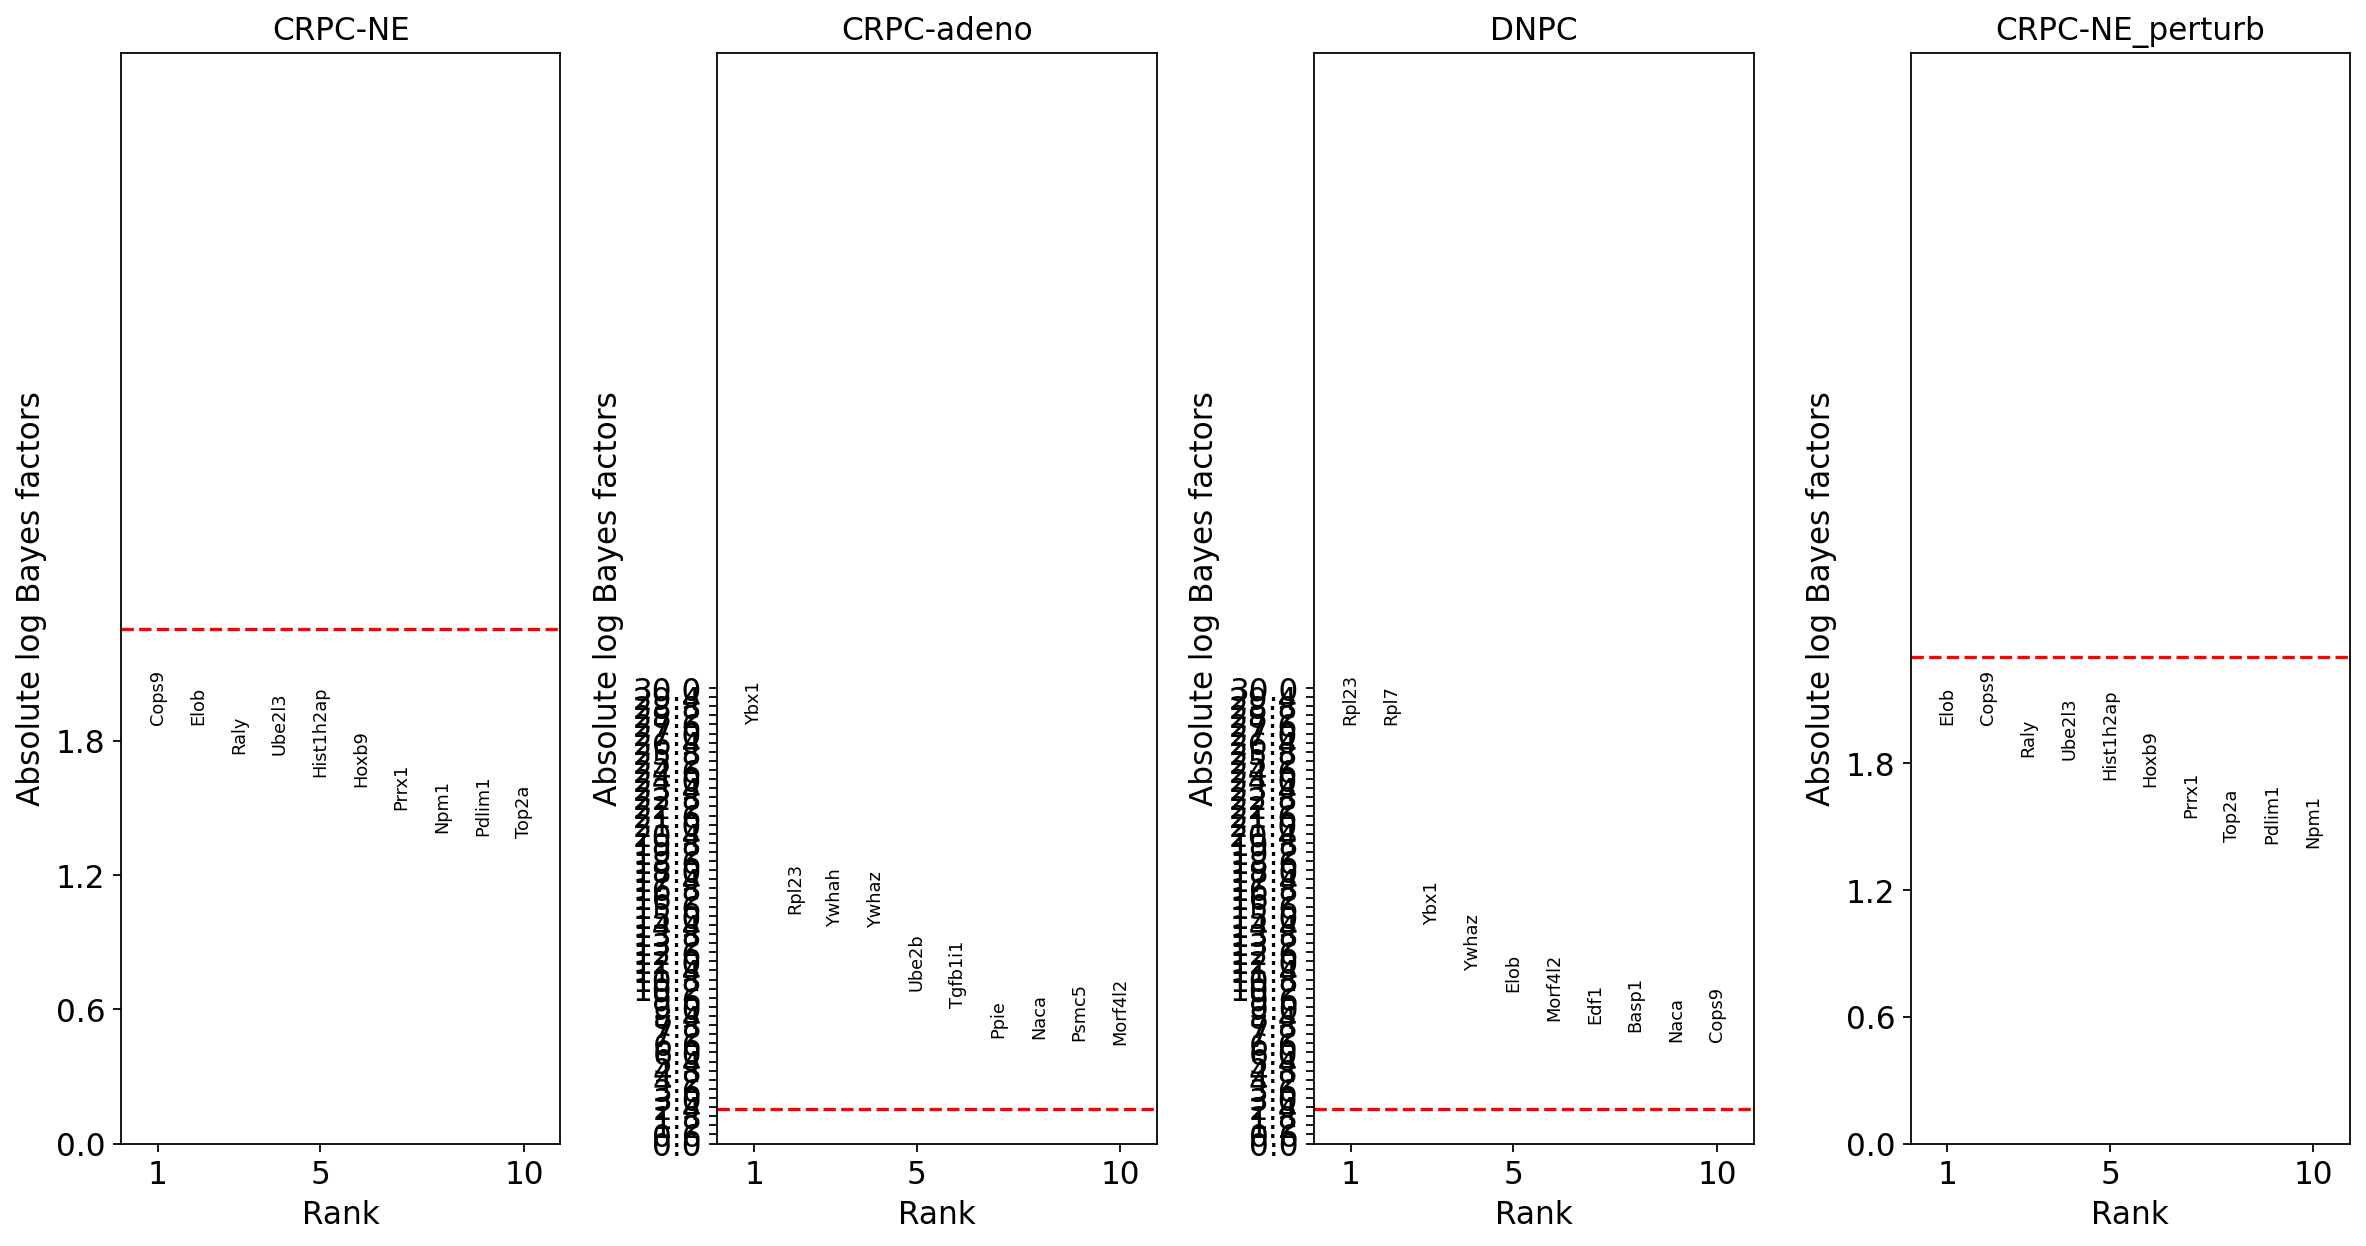

In [17]:
vae.latent_directions(adata=pert_gp_adata)
n_samples = min(pert_gp_adata.obs['cancer_subtype_perturb'].value_counts())
vae.latent_enrich(groups='cancer_subtype_perturb', use_directions=False, adata=pert_gp_adata, n_sample=n_samples)
pert_gp_adata.uns['terms'] = adata.uns['terms']
fig = sca.plotting.plot_abs_bfs(
    pert_gp_adata,
    n_cols=4,
    scale_y=2.6,
    yt_step=0.6,
    figsize=(15, 8),  # Increase figure size
    n_points=10,
)

In [18]:
ne_vs_adeno = ['CRPC-NE', 'CRPC-adeno']
all_groups   = 'all'
groups       = [ne_vs_adeno, all_groups]
dics = []

for grp in groups:
    result = vae.differential_expression(
        pert_gp_adata,
        groupby='cancer_subtype_perturb',
        method="wilcoxon",
        layer='perturbed_dec_mean',
        groups_to_compare=grp,
        reference=None
    )
    dics.append(result.uns['rank_genes_groups'])

Subsetted to groups: ['CRPC-NE', 'CRPC-adeno']
Differential expression completed.
Differential expression completed.


In [19]:
#adata.write_h5ad('/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/notebooks/perturbation_adata.h5ad')